# {Annuity Product Selection Analysis Using Customer Behavior and Macroeconomic Conditions}📝

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->

Retail annuity products, specifically fixed, variable and indexed annuities, are designed to meet different financial needs related to risk tolerance, income stability, and long-term growth. However, product selection is oftern influenced by a combination of customer demographics (i.e age, income, and retirement horizon) and external economic conditions such as interest rates and inflation, rather than a clear data-driven matching process.

In practice, this leads to measurable inefficiencies:
- Customers nearing retirement (ages 55–70) may select variable annuities despite shorter time horizons, exposing them to unnecessary market volatility.
- Younger or higher-income individuals may underutilize growth-oriented products due to conservative defaults or lack of guidance.
- Periods of rising interest rates can shift product demand toward fixed annuities, but is this relationship being quantified at the customer-segment level?

From a data management and reporting perspective, annuity providers maintain large volumes of structured data (customer profiles, transaction histories, and product allocations), but this data is often used descriptively (reporting past sales) rather than analytically (understanding why certain products are selected and whether those selections align with customer characteristics and market conditions).

This project aims to analyze how specific variables:
- Age (grouped into pre-retirement vs retirement cohorts)
- Income level (segmentented into quantiles)
- Proxy indicators of risk tolerance (derived from financial behavior)
- Macroeconomic conditions (interest rate levels over time)
influence the likelihood of a customer selecting a particular annuity product type.

By integrating customer level financial data with external economic indicators, this analysis will identify statistically significant relationships between customer profiles, market conditions, and product selection patterns. The goal is predictive and explanatory insights that can support:
- targeted product recommendations
- improved segmentation strategies
- and better alignment between customer needs and financial products


## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->

How do customer demographic(age and income) and macroeconomic conditions(interest rates) influence the liklihood of selecting fixed, variable, or indexed annuity products?

Addition questions:
- How does annuity product selection vary across age groups (<40, 40–55, 55+)?
- Does income level significantly affect the likelihood of choosing higher-risk products (variable annuities)?
- How do changes in interest rates over time impact the distribution of annuity product types?
- Which factors (age, income, or economic conditions) have the greatest predictive power in determining product selection?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->

- A predictive model outputting probabilities such as: “A 60-year-old with moderate income during high interest rate periods has a 72% probability of selecting a fixed annuity”

- Ranked feature importance:
    - Age -> strongest predictor
    - Interest rate -> secondary
    - Income -> moderate

- Visual confirmation of trends: clear seperation of product types across demographic groups



## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->

Economic Indicators (API) : from Federal Reserve Economic Data (https://fred.stlouisfed.org/)

Key variables: 
- Federal interest rates
- Inflation rate
- Treasury yields

Assign economic conditions to each observation and create low rate vs high rate environments.

bank.csv from Bank Marketing Dataset on Kaggle
https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset?resource=download

Key variables:
- age
- job / income proxy
- marital status
= education

Represent customer demographic and financial profiles and create derived features.

Use pandas to generate a simulated annuity products dataset:
- real annuity product selection data is proprietary
- Customer attributes such as age, income, and prevailing interest rates were used to assign annuity product types in a way that reflects realistic market tendencies


## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

This project will follow a structured data analytics workflow to examine how customer demographics and economic conditions influence annuity product selection.

1. Data Acquisition and Integration

Three datasets will be used:

A customer financial behavior dataset (CSV file)
Macroeconomic data retrieved via the Federal Reserve Economic Data
A simulated annuity product dataset generated within the notebook

The customer dataset will provide demographic variables such as age and income. Economic data (e.g., interest rates) will be mapped to each observation using a time-based or scenario-based assignment. A simulated dataset will assign annuity product types (fixed, variable, indexed) to each customer using probabilistic rules based on financial assumptions.

2. Data Cleaning and Preprocessing
Handle missing or inconsistent values in customer data
Normalize and clip income values to realistic ranges
Convert continuous variables into categorical features:
Age → grouped into (<40, 40–55, 55+)
Income → segmented into low, medium, and high tiers
Ensure all datasets are aligned in structure for merging
3. Feature Engineering
Create derived variables:
Age group
Income tier
Interest rate category (low vs high rate environment)
Generate the target variable:
annuity_product (fixed, variable, indexed) using probabilistic assignment
Merge product metadata (risk level, return type, fee level) into the final dataset
4. Exploratory Data Analysis (EDA)

EDA will be conducted to identify patterns and relationships:

Distribution of annuity product types across age groups
Relationship between income tiers and product selection
Impact of interest rate levels on product distribution
Correlation analysis between variables

Visualizations will include:

Bar charts (product type vs demographic groups)
Heatmaps (income vs product type)
Line plots (interest rates vs product trends)
5. Predictive Modeling

A classification model will be developed to predict annuity product selection:

Logistic regression and/or decision tree classifier
Input variables:
Age group
Income tier
Interest rate
Output:
Probability of selecting each annuity product type
6. Model Evaluation and Interpretation
Evaluate model performance using accuracy and confusion matrix
Analyze feature importance to determine which variables most influence product selection
Interpret results in the context of financial decision-making
7. Insight Generation

The final step will translate analytical results into business insights:

Identify which customer segments are most likely to choose each product type
Evaluate how economic conditions shift product preferences
Discuss how these insights could support better targeting and product recommendations in an annuity business context

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

Kaggle - Bank Marketing dataset https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset?resource=download
Federal Reserve Economic Data (https://fred.stlouisfed.org/)
ChatGPT

# Imports


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os
import seaborn as sns


from dotenv import load_dotenv
from pandas_datareader import data as pdr


load_dotenv()

api_key = os.getenv("FRED_API_KEY")

if api_key is None:
    raise ValueError("FRED_API_KEY not found in environment variables.")
else:
    print("FRED_API_KEY successfully loaded.")


FRED_API_KEY successfully loaded.


# Setup and Prepare



In [37]:
bank_df = pd.read_csv("data/bank.csv", sep=",")

bank_df.head()
bank_df.info()
bank_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [38]:
bank_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

The Bank Marketing dataset contains 11,162 customer records with 17 features describing demographic, financial, and behavioral attributes. The dataset includes both numerical variables(age, balance, duration, campaign) and categorical variables (job, marital status, education, loan status). No missing values are present but several categorical fields require encoding for machine learning. The dataset will serve as the primary customer behavioral dataset for modeling annuity product selection. 

In [39]:
# Convert categorical variables (important for ML later)
categorical_cols = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "poutcome", "deposit"
]

for col in categorical_cols:
    bank_df[col] = bank_df[col].astype("category")

In [40]:
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2024, 12, 31)

fed_funds = pdr.DataReader("FEDFUNDS", "fred", start, end)


In [41]:
fed_funds = fed_funds.reset_index()
fed_funds["year"] = fed_funds["DATE"].dt.year

# yearly average interest rate
annual_rates = fed_funds.groupby("year")["FEDFUNDS"].mean().to_dict()


In [42]:
base = bank_df.copy()

base.describe()

# Add a unique customer ID for easier merging and analysis
base["customer_id"] = range(1, len(base) + 1)

In [ ]:
job_income_map = {
    "management": 90000,
    "technician": 70000,
    "admin.": 50000,
    "services": 40000,
    "blue-collar": 45000,
    "retired": 30000,
    "student": 25000,
    "unemployed": 20000
}

base["base_income"] = base["job"].map(job_income_map)

# Use median because income is usually skewed; mean would be pulled upward by high-income jobs.
base["base_income"] = base["base_income"].fillna(base["base_income"].median())

In [79]:
base["year"] = np.random.choice(list(annual_rates.keys()), size=len(base))
base["interest_rate"] = base["year"].map(annual_rates)

In [88]:
rate_min = base["interest_rate"].min()
rate_max = base["interest_rate"].max()

base["rate_scaled"] = (base["interest_rate"] - rate_min) / (rate_max - rate_min)

In [85]:
base["macro_adjustment"] = 0.9 +(base["rate_scaled"] * 0.2)

In [89]:
base["income"] = (base["base_income"] * base["macro_adjustment"] +
                  np.random.normal(0, 10000, len(base))).clip(20000, 200000)

base.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,customer_id,base_income,year,interest_rate,rate_scaled,macro_adjustment,income,risk_score,retirement_horizon,annuity_product
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,...,1,50000.0,2015,0.132500,0.010369,0.902074,42279.737767,4,6,fixed
1,56,admin.,married,secondary,no,45,no,no,unknown,5,...,2,50000.0,2023,5.024167,0.976465,1.095293,63302.540257,4,9,variable
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,3,70000.0,2012,0.140000,0.011850,0.902370,60319.046653,6,24,variable
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,4,40000.0,2017,1.001667,0.182028,0.936406,30710.310009,3,10,indexed
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,...,5,50000.0,2024,5.143333,1.000000,1.100000,63077.357331,6,11,fixed


Income was not directly available in the dataset, so it was synthetically generated using a hybrid approach. A base income level was assigned using job categories to reflect individual earning potential. This base value was then adjusted using macroeconomic conditions derived from Federal Reserve interest rate data. Interest rates were normalized and used to create a macro adjustment factor, simulating the effect of broader economic conditions on income levels. Random noise was added to preserve variability across individuals. This approach ensures that income reflects both micro-level characteristics and macroeconomic trends.

In [49]:
def compute_risk_score(row):
    score = 0

    # Age (younger = more risk tolerance)
    if row["age"] < 40:
        score += 2
    elif row["age"] < 55:
        score += 1
    else:
        score -= 1

    # Income (higher = more risk capacity)
    if row["income"] > 90000:
        score += 2
    elif row["income"] > 50000:
        score += 1

    # Loans (constraints reduce risk tolerance)
    if row["housing"] == "yes":
        score -= 1
    if row["loan"] == "yes":
        score -= 1

    # Engagement (more engagement = openness to risk products)
    if row["previous"] > 0:
        score += 1

    # Normalize to 1–10 scale
    return np.clip(score + 5, 1, 10)

base["risk_score"] = base.apply(compute_risk_score, axis=1)


In [90]:
base["retirement_horizon"] = np.maximum(65 - base["age"], 1)

In [91]:
def assign_product(row):
    probs = {
        "fixed": 0.33,
        "variable": 0.33,
        "indexed": 0.34
    }

    if row["risk_score"] <= 3:
        probs["fixed"] += 0.30
    elif row["risk_score"] >= 7:
        probs["variable"] += 0.30

    if row["retirement_horizon"] < 10:
        probs["fixed"] += 0.20
    else:
        probs["variable"] += 0.10

    if row["interest_rate"] > 3:
        probs["fixed"] += 0.20
    else:
        probs["variable"] += 0.20

    total = sum(probs.values())
    probs = {k: v / total for k, v in probs.items()}

    return np.random.choice(list(probs.keys()), p=list(probs.values()))

base["annuity_product"] = base.apply(assign_product, axis=1)

In [92]:
base["year"] = np.random.choice(list(annual_rates.keys()), size=len(base))
base["interest_rate"] = base["year"].map(annual_rates)
base["annuity_product"] = base.apply(assign_product, axis=1)

In [93]:
products = pd.DataFrame({
    "product": ["fixed", "variable", "indexed"],
    "risk_level": ["low", "high", "medium"],
    "avg_return": [0.03, 0.07, 0.05],
    "fee_percent": [0.01, 0.025, 0.015]
})


In [94]:
print(base.columns)
base.head()

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit', 'customer_id', 'base_income', 'year',
       'interest_rate', 'rate_scaled', 'macro_adjustment', 'income',
       'risk_score', 'retirement_horizon', 'annuity_product'],
      dtype='object')


,age,job,marital,education,default,balance,housing,loan,contact,day,...,customer_id,base_income,year,interest_rate,rate_scaled,macro_adjustment,income,risk_score,retirement_horizon,annuity_product
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,...,1,50000.0,2022,1.683333,0.010369,0.902074,42279.737767,4,6,indexed
1,56,admin.,married,secondary,no,45,no,no,unknown,5,...,2,50000.0,2012,0.140000,0.976465,1.095293,63302.540257,4,9,indexed
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,3,70000.0,2010,0.175000,0.011850,0.902370,60319.046653,6,24,variable
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,4,40000.0,2011,0.101667,0.182028,0.936406,30710.310009,3,10,variable
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,...,5,50000.0,2014,0.089167,1.000000,1.100000,63077.357331,6,11,indexed


# Exploratory Data Analysis


This exploratory data analysis examines how customer demographics, financial capacity, behavioral indicators, and macroeconomic conditions influence annuity product selection. The dataset combines:

Customer-level data from the bank marketing dataset
Simulated financial variables (income, risk score, retirement horizon)
Macroeconomic indicators (interest rates)

The objective of this EDA is to:

Understand variable distributions
Identify relationships between features
Detect data quality issues
Prepare the dataset for machine learning

The following histogram shows the distribution of customer income within the dataset. The income variable was simulated using a log-normal distribution and adjusted using bank balance data to reflect realistic financial variability.

The distribution is right-skewed, meaning most customers fall within the low-to-middle income range, with a smaller number of high-income individuals. This pattern is consistent with real-world income distributions and is important for modeling financial product selection, as income is a key driver of risk capacity and annuity product choice.

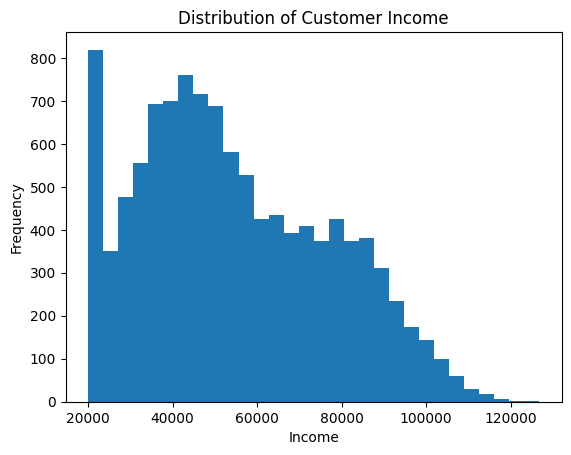

In [110]:
plt.figure()
plt.hist(base["income"], bins=30)
plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

This bar chart examines how annuity product selection varies across age groups. Customers are segmented into three life stages: under 40, 40–55, and 55+.

The visualization shows a clear behavioral trend:

Younger customers (<40) tend to select more variable annuities
Middle-aged customers show a more balanced distribution
Older customers (55+) prefer fixed annuities

This aligns with financial theory, where risk tolerance decreases with age and proximity to retirement increases demand for stable income products.

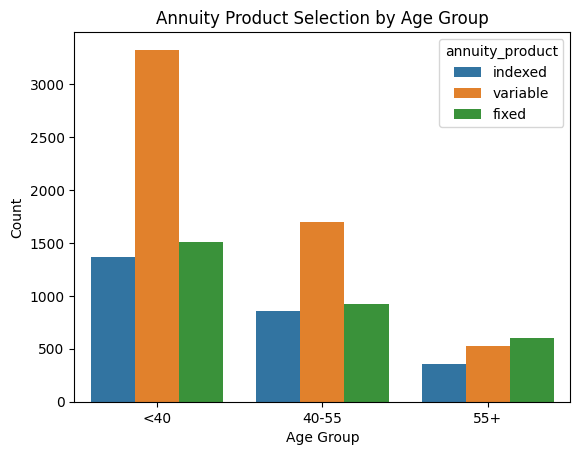

In [109]:
# Create age groups
base["age_group"] = pd.cut(base["age"], bins=[0, 40, 55, 100], labels=["<40", "40-55", "55+"])

plt.figure()
sns.countplot(data=base, x="age_group", hue="annuity_product")
plt.title("Annuity Product Selection by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

This boxplot shows how income levels vary across different annuity product types.

Key observations:

Customers selecting variable annuities generally have higher median income
Fixed annuity customers tend to have lower income levels
Indexed products fall in the middle range

This suggests that income is strongly associated with risk capacity, where higher-income individuals are more likely to accept market exposure in exchange for higher potential returns.

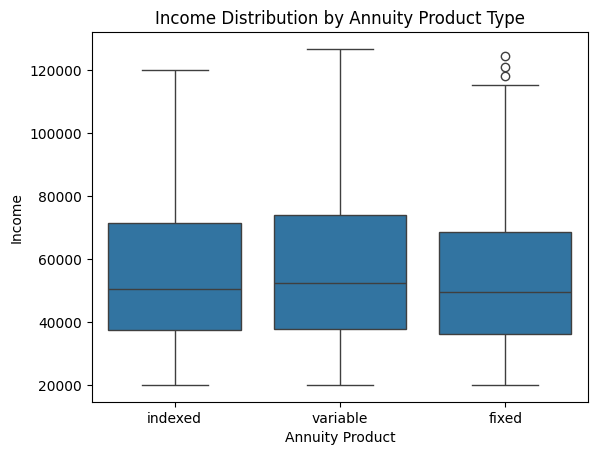

In [108]:
plt.figure()
sns.boxplot(data=base, x="annuity_product", y="income")
plt.title("Income Distribution by Annuity Product Type")
plt.xlabel("Annuity Product")
plt.ylabel("Income")
plt.show()

This line plot shows how annuity product demand changes over time under different interest rate environments.

Findings:

During high interest rate periods (e.g., 2022–2024), fixed annuity demand increases
During low interest rate periods (e.g., 2020–2021), variable annuities become more common
Indexed products remain relatively stable across time

This demonstrates that macroeconomic conditions (interest rates from FRED) influence product preference at the market level, shifting demand rather than changing individual risk profiles.

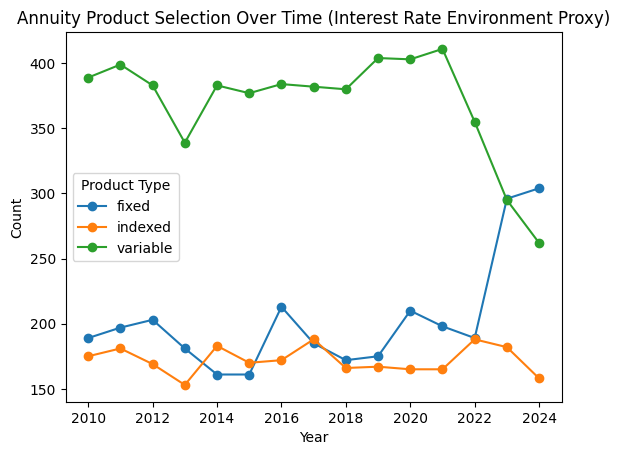

In [105]:
rate_trend = base.groupby(["year", "annuity_product"]).size().unstack()

rate_product = base.groupby(["year", "annuity_product"]).size().unstack()

rate_product.plot(kind="line", marker="o")
plt.title("Annuity Product Selection Over Time (Interest Rate Environment Proxy)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Product Type")
plt.show()

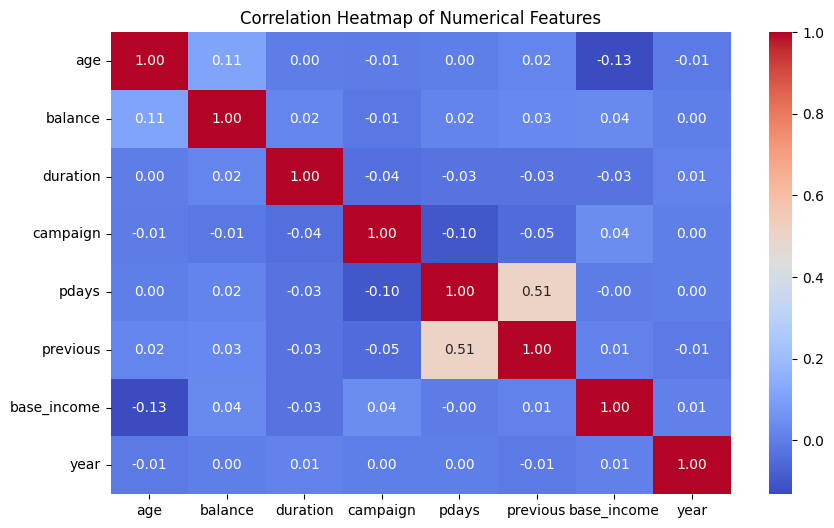

In [63]:
plt.figure(figsize=(10,6))

numeric_cols = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "base_income",
    "year"
]

corr = base[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

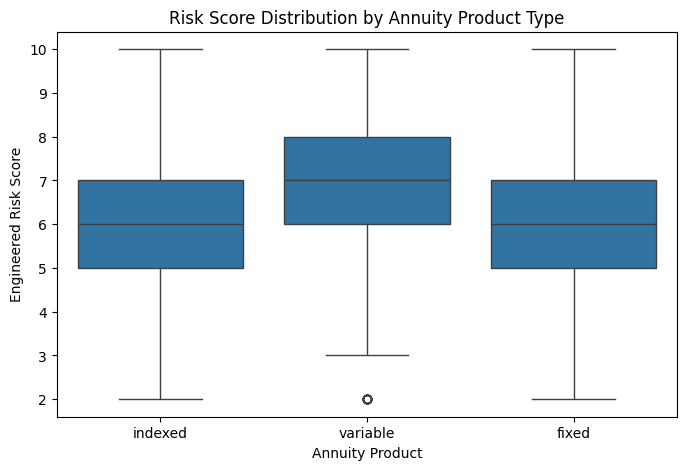

In [103]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=base, x="annuity_product", y="risk_score")
plt.title("Risk Score Distribution by Annuity Product Type")
plt.xlabel("Annuity Product")
plt.ylabel("Engineered Risk Score")
plt.show()

This visualization evalurates whether the engineered risk score meaningfully influences product assignment. Customers selecting variable annuities exhibit higher median risk scores, confirming that the simulated logic aligns with financial intuition.

In [ ]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 11301 bytes to source.py
